<a href="https://colab.research.google.com/github/tfiorio/pos-pucrio/blob/spring01/Spring01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Thompson Fiorio

**Matrícula:** 4052025002903

**Dataset:** [Spotify Tracks](https://github.com/tfiorio/pos-pucrio/blob/spring01/spotify_tracks.csv)

# 1. Descrição do Problema

O dataset que irei analisar é composto de faixas de música existentes no Spotify. Pretendo identificar a relevância do gênero Rock e seus subgêneros diante dos demais gêneros existentes no dataset. Para entender a representatividade do gênero Rock diante dos demais estilos musicais, iremos utilizar métricas de engajamento (como popularidade) e qual gênero de Rock possui maior potencial de sucesso na plataforma.









## Hpóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Sabemos que o Rock tem uma grande diversidade de subgêneros. Podemos encontrar e distinguir cada subgênero?**

2. **Quais subgêneros são mais populares no Spotify?**

3. **Gêneros mais extremos tem uma popularidade muito diferente dos gêneros mais clássicos como o "pop rock"?**


## ⚠️ Restrições

- A análise será restrita exclusivamente ao dataset fornecido
- Não serão utilizados dados externos








## Tipo de Problema

Problema de **classificação supervisionada**. Trata-se de uma análise de dados com foco no agrupamento e estatística de gêneros do Rock no Spotify, onde iremos tentar identificar quais dos subgêneros existentes na plataforma são mais populares e o relevância geral do Rock ante os demais gêneros



## Seleção de Dados

Os dados foram coletados usando a API Web do Spotify por meio de um script em Python. O script realizou buscas por diferentes gêneros musicais e recuperou as faixas mais populares de cada gênero. Os dados obtidos foram então compilados e salvos em um arquivo CSV. Esse dataset foi encontrado no kaggle.

## Atributos do Dataset

O dataset spotify_track possui 6300 registros com o atributos:

- ***id:*** Identificador único da faixa no Spotify.
- ***name:*** Nome da faixa.
- ***genre:*** Gênero da música.
- ***artists:*** Nomes dos artistas que interpretaram a música, separados por vírgulas se houver mais de um artista.
- ***album:*** Nome do álbum ao qual a faixa pertence.
- ***popularity:*** Índice de popularidade da faixa (0-100, onde quanto maior, mais popular).
- ***duration_ms:*** Duração da faixa em milissegundos.
- ***explicit:*** Valor booleano que indica se a faixa contém conteúdo explícito.

# 2. Carga de Dados e Bibliotecas

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset spotify_track.



In [4]:
# Importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")

# Carga do dataset via GitHub (URL Raw para o Colab ler corretamente)
url = "https://raw.githubusercontent.com/tfiorio/pos-pucrio/refs/heads/spring01/spotify_tracks.csv"
df = pd.read_csv(url)

df_estudo = df

df_estudo.head()


,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,acoustic,The Goo Goo Dolls,Dizzy up the Girl,46,116573,False
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,acoustic,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),33,133922,False


#3. Análise de Dados (Estatística e Visualização)

## 📊 Estrutura do Dataset

Nesta etapa, buscamos compreender a estrutura geral do dataset, incluindo quantidade de registros, tipos de dados e características gerais.

Checklist Inicial:

- **Instâncias e Atributos:** O dataset possui df.shape[0] linhas e df.shape[1] colunas.
- **Tipos de dados:** Temos dados numéricos (float/int) e categóricos (object).
- **Valores Faltantes:** Verificaremos abaixo se existem nulos.

In [6]:
# Total de registro e atributos existentes no dataset
df_estudo.shape

(6300, 8)

In [7]:
# Visão geral dos tipos de dados
df_estudo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           6300 non-null   object
 1   name         6300 non-null   object
 2   genre        6300 non-null   object
 3   artists      6300 non-null   object
 4   album        6300 non-null   object
 5   popularity   6300 non-null   int64 
 6   duration_ms  6300 non-null   int64 
 7   explicit     6300 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 350.8+ KB


In [12]:
# Resumo estatístico das variáveis numéricas
display(df_estudo.describe())

,popularity,duration_ms
count,6300.000000,6.300000e+03
mean,30.754762,2.028477e+05
std,19.948991,1.210299e+05
min,0.000000,3.006000e+04
25%,16.000000,1.476870e+05
50%,29.000000,1.916070e+05
75%,45.000000,2.369625e+05
max,90.000000,3.601658e+06


In [13]:
# Verificação de valores
display("Valores ausentes por coluna:")
display(df_estudo.isnull().sum())

'Valores ausentes por coluna:'

,0
id,0
name,0
genre,0
artists,0
album,0
popularity,0
duration_ms,0
explicit,0


In [14]:
# Valores faltantes
df_estudo.isnull().sum()

,0
id,0
name,0
genre,0
artists,0
album,0
popularity,0
duration_ms,0
explicit,0


### 🧠 Análise

O dataset estudado, possui um quantidade significativa de registros, desta forma, nossa análise trará informações que poderão ser mais próximas do real.

Podemos observar variáveis numéricas, categóricas e descritivas, sendo a variável **"popularity"** essencial para este estudo.

As estatísticas descritivas indicam a distribuição dos valores numéricos, permitindo identificarmos possíveis outliers e padrões iniciais.

A verificação de valores faltantes é essencial para garantirmos a qualidade do dado que iremos analisar.

Neste dataset, observa-se que todos os registros estão completos, não sendo necessário intervenção alguma. Caso houvessem valores nulos, seria necessário o tratamento dos dados para evitar distorções nos resultados.

#4. CRIAÇÃO DA VARIÁVEL ROCK

Será criada uma variável booleana chamada **is_rock** para identificar músicas pertencentes ao gênero Rock e seus subgêneros. Essa abordagem permite segmentar os dados de forma eficiente.

In [17]:
# Identificando os gêneros musicais existentes no dataset
display(df_estudo['genre'].unique())

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'bossanova',
       'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house',
       'children', 'chill', 'classical', 'club', 'comedy', 'country',
       'dance', 'dancehall', 'death-metal', 'deep-house',
       'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub',
       'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro',
       'french', 'funk', 'garage', 'german', 'gospel', 'goth',
       'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock',
       'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'holidays',
       'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop',
       'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock',
       'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop',
       'metal', 'metal-misc', 'metalcore', 'minimal-techno', 'movies',
       'mpb', 'new-age', 'new-releas

In [20]:
# Criação da lista de gêneros de rock encnotrados no dataset
rock_genre = ['alt-rock', 'alternative', 'black-metal', 'death-metal', 'folk', 'goth', 'grindcore', 'grunge', 'guitar', 'hard-rock', 'hardcore', 'heavy-metal', 'indie', 'indie-pop', 'industrial', 'metal', 'metal-misc', 'metalcore', 'psych-rock', 'punk', 'punk-rock', 'road-trip', 'rock', 'rock-n-roll', 'rockabilly']

# Criação da variável booleana
df_estudo['is_rock'] = df_estudo['genre'].isin(rock_genre)

rock_df_estudo = df_estudo[df_estudo['is_rock']]

##⚖️ 6. ROCK vs OUTROS GÊNEROS



In [21]:
# Diferença entre Orck e outros gêneros
rock_popularity = rock_df_estudo['popularity'].mean()
other_popularity = df_estudo[~df_estudo['is_rock']]['popularity'].mean()

rock_popularity, other_popularity

(np.float64(28.3312), np.float64(31.354653465346534))

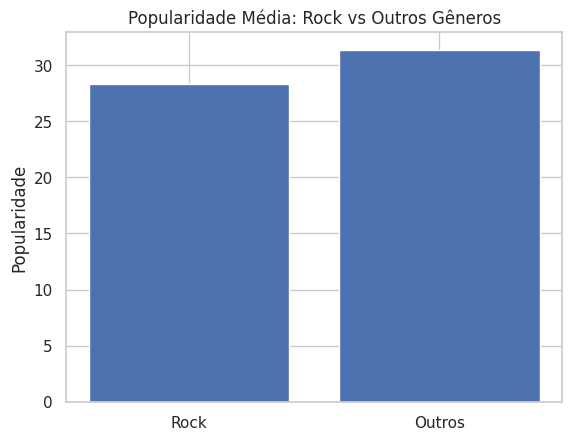

In [22]:
# Geração de gráfico para melhor entendimento
plt.figure()
plt.bar(['Rock', 'Outros'], [rock_popularity, other_popularity])
plt.title('Popularidade Média: Rock vs Outros Gêneros')
plt.ylabel('Popularidade')
plt.show()

### 🧠 Análise

Na comparação entre a popularidade média do Rock e os demais gêneros, nos mostra uma diferença pequena. Devido a esse proximidade na popularidade, podemos identificar que o Rock se mantem com uma significativa relevância no cenário musical.

## 🎸 7. SUBGÊNEROS MAIS POPULARES

In [29]:
# Criação de uma variável para visualizar a popularidade de cada subgenero da lista
rock_pop_by_genre = rock_df_estudo.groupby('genre')['popularity'].mean().sort_values(ascending=False)

rock_pop_by_genre.head(10)

,popularity
genre,
rock,60.34
rock-n-roll,53.54
metal,40.54
punk,36.28
guitar,36.20
hardcore,34.84
death-metal,34.80
hard-rock,33.56
metalcore,31.60


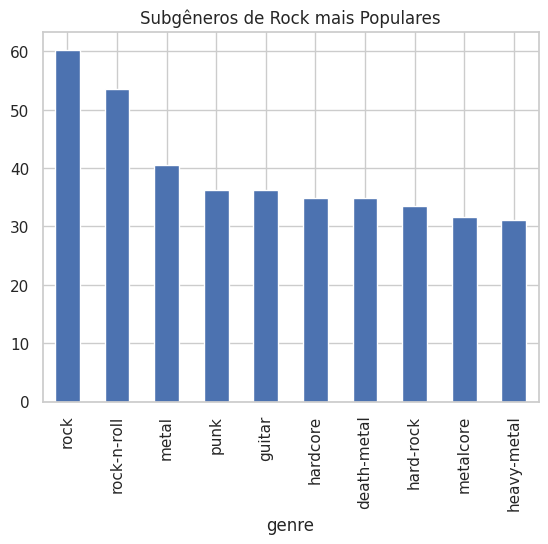

In [30]:
# Criação de gráfica para melhor visualização dos dados
rock_pop_by_genre.head(10).plot(kind='bar')
plt.title('Subgêneros de Rock mais Populares')
plt.show()

### 🧠 Análise

A análise da popularidade média por subgênero permite identificar quais estilos são mais bem aceitos pelo público. Subgêneros mais populares tendem a ter maior alcance comercial e presença em playlists.

Nesta comparação podemos identificar que o rock "clássico" é gênero mais ouvido pelo público

## ⚡ 8. ROCK EXTREMO vs ROCK CLÁSSICO

In [31]:
extreme = rock_df_estudo[rock_df_estudo['genre'].str.contains('metal|hardcore|punk|hard', case=False)]
classic = rock_df_estudo[rock_df_estudo['genre'].str.contains('rock|indie|industrial', case=False)]

extreme_mean = extreme['popularity'].mean()
classic_mean = classic['popularity'].mean()

extreme_mean, classic_mean

(np.float64(30.414), np.float64(29.134))

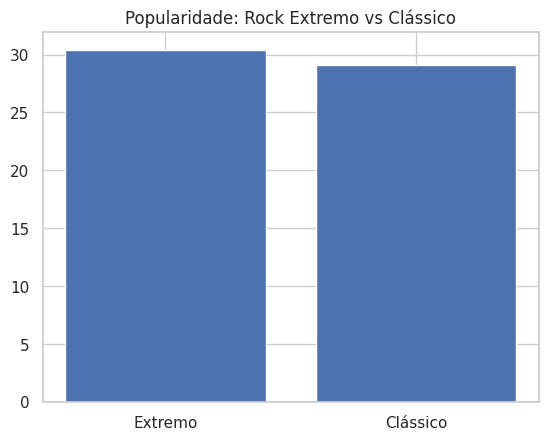

In [32]:
plt.figure()
plt.bar(['Extremo', 'Clássico'], [extreme_mean, classic_mean])
plt.title('Popularidade: Rock Extremo vs Clássico')
plt.show()

### 🧠 Análise

A comparação entre subgêneros extremos e clássicos evidencia diferenças no perfil de consumo.

Aqui temos uma informação interessante, pois a pequena vantagem que o rock extremo leva sobre o rock clássico, deve ser devido as quantidade de subgêneros que compõem o rock extremo.

## 🧹 10. PRÉ-PROCESSAMENTO
### Pré-processamento de Dados

Nesta etapa, realizamos transformações para melhorar a qualidade e padronização dos dados.

---



In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['popularity_norm'] = scaler.fit_transform(df[['popularity']])

### 🧠 Análise

A normalização foi aplicada para padronizar os valores de popularidade entre 0 e 1.

Essa técnica é importante para análises futuras e algoritmos que dependem da escala dos dados.

## 🧾 12. CONCLUSÃO

### 📌 Conclusão

A análise permitiu compreender o comportamento do gênero Rock dentro do dataset.

Os principais achados incluem:

- O Rock apresenta uma pequena desvantagem em comparação com os demais gêneros musicais, dentro do universo deste dataset.
- Subgêneros como "rock" e "rock-n-roll" se destacam em representatividade
- O subgênero mais popular é "rock"
- Gêneros extremos tendem a menor popularidade em relação aos clássicos
- Existem mais gêneros de rock extremo do que clássicos

De forma geral, os resultados indicam que o Rock mantém relevância, mas apresenta variações internas significativas entre seus subgêneros.

